In [1]:
import pandas as pd

ggg = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\GGG.csv")

print(ggg.shape)
print(ggg.columns.tolist())

(2534, 38)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'ass_6_date', 'ass_6_score', 'ass_7_date', 'ass_7_score', 'ass_8_date', 'ass_8_score', 'ass_9_date', 'ass_9_score', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucontent', 'clicks_quiz', 'clicks_resource', 'clicks_subpage']


In [3]:
demographics = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                 'num_of_prev_attempts', 'studied_credits', 'disability']

assessment_cols = [f'ass_{i}_score' for i in range(1, 10)]

click_cols = ['clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucontent',
              'clicks_quiz', 'clicks_resource', 'clicks_subpage']

selected_cols = demographics + assessment_cols + click_cols + ['final_result']

ggg_sel = ggg[selected_cols].copy()
print(ggg_sel.shape)
ggg_sel.head()

(2534, 25)


,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,ass_1_score,ass_2_score,...,ass_8_score,ass_9_score,clicks_forumng,clicks_glossary,clicks_homepage,clicks_oucontent,clicks_quiz,clicks_resource,clicks_subpage,final_result
0,M,East Midlands Region,A Level or Equivalent,80-90%,0-35,0,30,N,80.0,80.0,...,80.0,100.0,62.0,2.0,130.0,357.0,120.0,18.0,23.0,Distinction
1,M,North Western Region,Lower Than A Level,10-20,35-55,0,30,N,66.0,53.0,...,100.0,100.0,118.0,1.0,315.0,151.0,105.0,83.0,13.0,Pass
2,F,London Region,A Level or Equivalent,30-40%,0-35,0,30,N,55.0,55.0,...,80.0,NaN,140.0,0.0,181.0,178.0,88.0,18.0,15.0,Pass
3,F,East Midlands Region,Lower Than A Level,70-80%,35-55,0,30,N,80.0,70.0,...,NaN,NaN,3.0,0.0,24.0,36.0,1.0,3.0,10.0,Fail
4,F,Yorkshire Region,A Level or Equivalent,10-20,35-55,0,30,N,78.0,90.0,...,60.0,100.0,127.0,4.0,176.0,360.0,143.0,27.0,15.0,Distinction


In [5]:
print("imd_band unique values:")
print(ggg_sel['imd_band'].unique())
print()
print("imd_band NaN count:", ggg_sel['imd_band'].isna().sum())
print()
print("NaN counts - assessment scores:")
print(ggg_sel[assessment_cols].isna().sum())
print()
print("NaN counts - click columns:")
print(ggg_sel[click_cols].isna().sum())

imd_band unique values:
['80-90%' '10-20' '30-40%' '70-80%' nan '40-50%' '90-100%' '50-60%'
 '0-10%' '60-70%' '20-30%']

imd_band NaN count: 7

NaN counts - assessment scores:
ass_1_score     495
ass_2_score     641
ass_3_score     810
ass_4_score     687
ass_5_score     786
ass_6_score     871
ass_7_score     901
ass_8_score    1075
ass_9_score    1325
dtype: int64

NaN counts - click columns:
clicks_forumng      168
clicks_glossary     168
clicks_homepage     168
clicks_oucontent    168
clicks_quiz         168
clicks_resource     168
clicks_subpage      168
dtype: int64


In [7]:
ggg_sel['imd_band'] = ggg_sel['imd_band'].replace('10-20', '10-20%')

imd_mode = ggg_sel['imd_band'].mode()[0]
print("imd_band mode:", imd_mode)
ggg_sel['imd_band'] = ggg_sel['imd_band'].fillna(imd_mode)

print(ggg_sel['imd_band'].unique())

click_nan_mask = ggg_sel[click_cols].isna()
same_students = (click_nan_mask.sum(axis=1).isin([0, 7])).all()
print("All-or-nothing NaN pattern across clicks:", same_students)

ggg_sel[assessment_cols] = ggg_sel[assessment_cols].fillna(-1)
ggg_sel[click_cols] = ggg_sel[click_cols].fillna(0)

print(ggg_sel.isna().sum().sum())

imd_band mode: 10-20%
['80-90%' '10-20%' '30-40%' '70-80%' '40-50%' '90-100%' '50-60%' '0-10%'
 '60-70%' '20-30%']
All-or-nothing NaN pattern across clicks: True
0


In [9]:
final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
ggg_sel['final_result'] = ggg_sel['final_result'].map(final_result_map)

highest_ed_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
                     'HE Qualification', 'Post Graduate Qualification']
highest_ed_map = {v: i for i, v in enumerate(highest_ed_order)}
ggg_sel['highest_education'] = ggg_sel['highest_education'].map(highest_ed_map)

imd_order = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%',
             '60-70%', '70-80%', '80-90%', '90-100%']
imd_map = {v: i for i, v in enumerate(imd_order)}
ggg_sel['imd_band'] = ggg_sel['imd_band'].map(imd_map)

age_band_order = ['0-35', '35-55', '55<=']
age_band_map = {v: i for i, v in enumerate(age_band_order)}
ggg_sel['age_band'] = ggg_sel['age_band'].map(age_band_map)

ggg_sel['gender'] = ggg_sel['gender'].map({'M': 0, 'F': 1})
ggg_sel['disability'] = ggg_sel['disability'].map({'N': 0, 'Y': 1})

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ggg_sel['region'] = le.fit_transform(ggg_sel['region'])

print(ggg_sel.isna().sum().sum())
print(ggg_sel.dtypes)

0
gender                    int64
region                    int64
highest_education         int64
imd_band                  int64
age_band                  int64
num_of_prev_attempts      int64
studied_credits           int64
disability                int64
ass_1_score             float64
ass_2_score             float64
ass_3_score             float64
ass_4_score             float64
ass_5_score             float64
ass_6_score             float64
ass_7_score             float64
ass_8_score             float64
ass_9_score             float64
clicks_forumng          float64
clicks_glossary         float64
clicks_homepage         float64
clicks_oucontent        float64
clicks_quiz             float64
clicks_resource         float64
clicks_subpage          float64
final_result              int64
dtype: object


In [11]:
for col in click_cols:
    nonzero = (ggg_sel[col] != 0).sum()
    unique_vals = ggg_sel[col].nunique()
    print(f"{col}: {nonzero} nonzero / {unique_vals} unique values")

clicks_forumng: 1892 nonzero / 411 unique values
clicks_glossary: 1131 nonzero / 67 unique values
clicks_homepage: 2364 nonzero / 404 unique values
clicks_oucontent: 2277 nonzero / 598 unique values
clicks_quiz: 1989 nonzero / 248 unique values
clicks_resource: 2322 nonzero / 166 unique values
clicks_subpage: 2280 nonzero / 118 unique values


In [13]:
ggg_sel['total_clicks'] = ggg_sel[click_cols].sum(axis=1)
ggg_sel = ggg_sel.drop(columns=click_cols)

bin_cols = assessment_cols + ['total_clicks']

for col in bin_cols:
    binned = pd.qcut(ggg_sel[col], q=4, duplicates='drop')
    n_bins = binned.nunique()
    print(f"{col}: {n_bins} bins")
    ggg_sel[col] = binned.cat.codes

print()
print("Final shape:", ggg_sel.shape)
print(ggg_sel.columns.tolist())

ass_1_score: 4 bins
ass_2_score: 3 bins
ass_3_score: 3 bins
ass_4_score: 2 bins
ass_5_score: 2 bins
ass_6_score: 2 bins
ass_7_score: 2 bins
ass_8_score: 3 bins
ass_9_score: 1 bins
total_clicks: 4 bins

Final shape: (2534, 19)
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score', 'final_result', 'total_clicks']


In [15]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import numpy as np

data = ggg_sel.values.astype(float)
node_names = ggg_sel.columns.tolist()

nodes = {name: GraphNode(name) for name in node_names}

assessment_cols_ggg = [f'ass_{i}_score' for i in range(1, 10)]
demo_vars = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
             'num_of_prev_attempts', 'studied_credits', 'disability']
course_time_vars = assessment_cols_ggg + ['total_clicks', 'final_result']

bk = BackgroundKnowledge()

# Rule 1
for ct in course_time_vars:
    for d in demo_vars:
        bk.add_forbidden_by_node(nodes[ct], nodes[d])

# Rule 2
for name in node_names:
    if name != 'gender':
        bk.add_forbidden_by_node(nodes[name], nodes['gender'])

# Rule 3
for i in range(1, 10):
    for j in range(1, 10):
        if j > i:
            bk.add_forbidden_by_node(nodes[f'ass_{j}_score'], nodes[f'ass_{i}_score'])

# Rule 4
for ct in course_time_vars:
    bk.add_forbidden_by_node(nodes[ct], nodes['studied_credits'])
    bk.add_forbidden_by_node(nodes[ct], nodes['num_of_prev_attempts'])

# Rule 5
for a in assessment_cols_ggg:
    bk.add_forbidden_by_node(nodes['final_result'], nodes[a])

# Rule 6
for a in assessment_cols_ggg:
    bk.add_forbidden_by_node(nodes[a], nodes['total_clicks'])

# Rule 7
bk.add_forbidden_by_node(nodes['final_result'], nodes['total_clicks'])

cg = pc(data, alpha=0.05, indep_test='gsq', background_knowledge=bk, node_names=node_names)

print("PC complete.")
print("Number of edges:", cg.G.get_num_edges())

  0%|          | 0/19 [00:00<?, ?it/s]

PC complete.
Number of edges: 30


In [17]:
edges = cg.G.get_graph_edges()
for edge in edges:
    print(edge)

imd_band --> region
disability --> region
age_band --> highest_education
disability --> highest_education
age_band --> total_clicks
num_of_prev_attempts --- studied_credits
ass_1_score --> ass_2_score
ass_1_score --> ass_3_score
ass_1_score --> ass_4_score
ass_1_score --> final_result
total_clicks --> ass_1_score
ass_2_score --> ass_3_score
ass_2_score --> ass_4_score
ass_2_score --> ass_6_score
ass_3_score --> ass_5_score
ass_3_score --> final_result
total_clicks --> ass_3_score
ass_4_score --> ass_5_score
ass_4_score --> ass_7_score
total_clicks --> ass_4_score
ass_5_score --> ass_6_score
ass_5_score --> ass_7_score
total_clicks --> ass_5_score
ass_6_score --> final_result
ass_7_score --> ass_8_score
ass_7_score --> final_result
total_clicks --> ass_7_score
ass_8_score --> final_result
total_clicks --> ass_8_score
total_clicks --> final_result


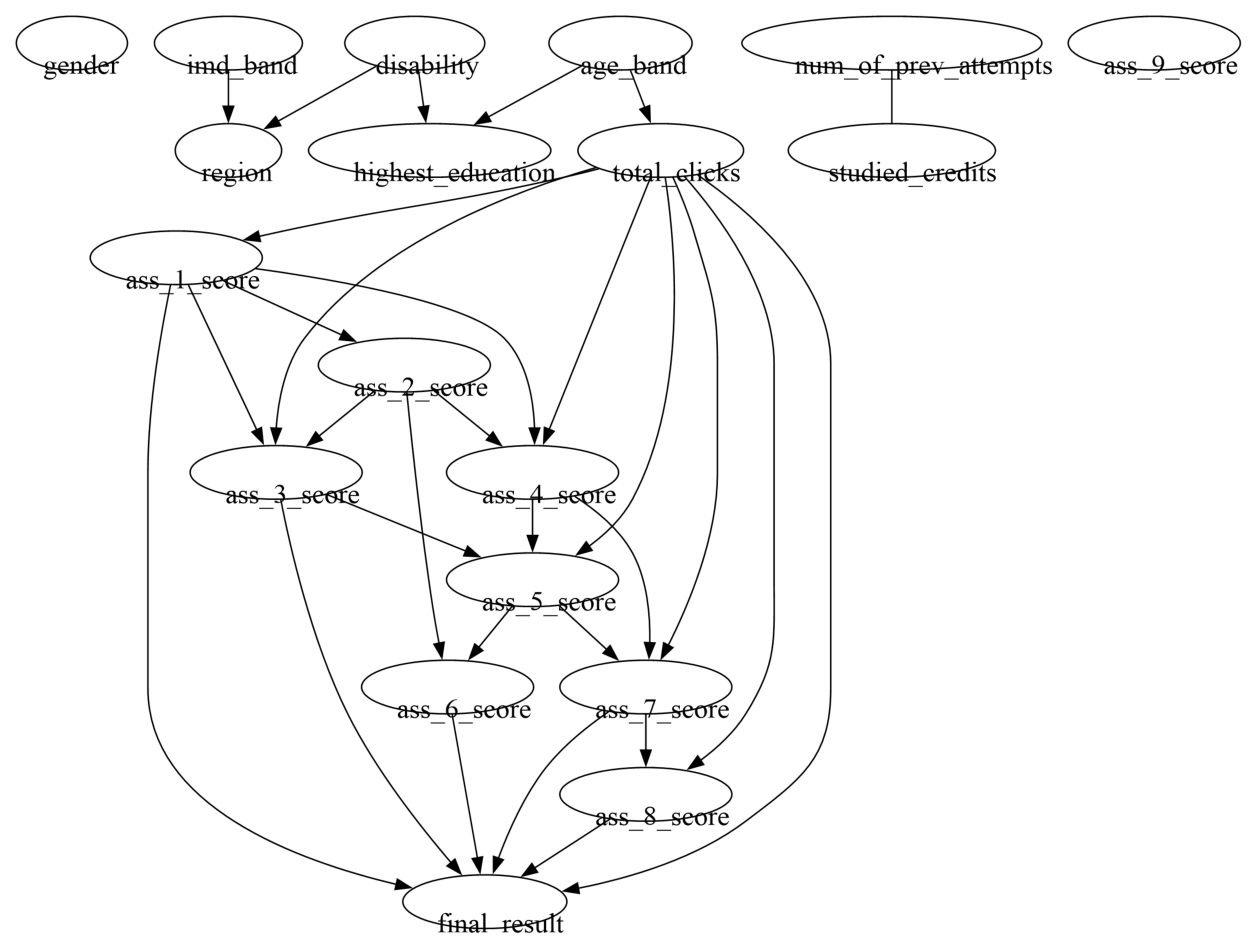

In [21]:
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

dot_path = r"C:\Users\Disha Sharma\.conda\envs\analytics\Library\bin\dot.exe"

pyd = GraphUtils.to_pydot(cg.G, labels=node_names)
png_data = pyd.create_png(prog=dot_path)

img = mpimg.imread(io.BytesIO(png_data))
plt.figure(figsize=(16, 12))
plt.imshow(img)
plt.axis('off')
plt.show()

# Domain specific DAGs

## Student Info vs Final Result 

In [26]:
df = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\GGG.csv")

print(df.shape)
print(list(df.columns))

(2534, 38)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'ass_6_date', 'ass_6_score', 'ass_7_date', 'ass_7_score', 'ass_8_date', 'ass_8_score', 'ass_9_date', 'ass_9_score', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucontent', 'clicks_quiz', 'clicks_resource', 'clicks_subpage']


In [28]:
print(df[['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'final_result']].dtypes)
print(df[['gender', 'highest_education', 'final_result']].head(3))

gender               object
region               object
highest_education    object
imd_band             object
age_band             object
disability           object
final_result         object
dtype: object
  gender      highest_education final_result
0      M  A Level or Equivalent  Distinction
1      M     Lower Than A Level         Pass
2      F  A Level or Equivalent         Pass


In [30]:
final_result_map = {'Withdrawn':0,'Fail':1,'Pass':2,'Distinction':3}
education_map = {'No Formal quals':0,'Lower Than A Level':1,'A Level or Equivalent':2,
                  'HE Qualification':3,'Post Graduate Qualification':4}
age_band_map = {'0-35':0,'35-55':1,'55<=':2}

print(df['imd_band'].unique())

df['final_result'] = df['final_result'].map(final_result_map)
df['highest_education'] = df['highest_education'].map(education_map)
df['age_band'] = df['age_band'].map(age_band_map)
df['gender'] = df['gender'].map({'M':0,'F':1})
df['disability'] = df['disability'].map({'N':0,'Y':1})
df['region'] = df['region'].astype('category').cat.codes

print(df[['gender', 'highest_education', 'age_band', 'final_result']].isnull().sum())

['80-90%' '10-20' '30-40%' '70-80%' nan '40-50%' '90-100%' '50-60%'
 '0-10%' '60-70%' '20-30%']
gender               0
highest_education    0
age_band             0
final_result         0
dtype: int64


In [32]:
imd_map = {'0-10%':0,'10-20%':1,'10-20':1,'20-30%':2,'30-40%':3,'40-50%':4,
           '50-60%':5,'60-70%':6,'70-80%':7,'80-90%':8,'90-100%':9}

df['imd_band'] = df['imd_band'].map(imd_map)

print("NaN before mode-fill:", df['imd_band'].isnull().sum())

imd_mode = df['imd_band'].mode()[0]
df['imd_band'] = df['imd_band'].fillna(imd_mode)

print("NaN after mode-fill:", df['imd_band'].isnull().sum())
print("Mode used:", imd_mode)

NaN before mode-fill: 7
NaN after mode-fill: 0
Mode used: 1.0


In [35]:
demo_cols_ggg = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                  'num_of_prev_attempts', 'studied_credits', 'disability']

dag1_data_ggg = df[demo_cols_ggg + ['final_result']].copy()

print(dag1_data_ggg.shape)
print(dag1_data_ggg.isnull().sum())

(2534, 9)
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64


In [37]:
node_names_dag1_ggg = list(dag1_data_ggg.columns)
nodes_dag1_ggg = [GraphNode(name) for name in node_names_dag1_ggg]

bk1_ggg = BackgroundKnowledge()

gender_node_ggg = nodes_dag1_ggg[node_names_dag1_ggg.index('gender')]
final_result_node_ggg = nodes_dag1_ggg[node_names_dag1_ggg.index('final_result')]

# Rule 2: nothing causes gender (root)
for n in nodes_dag1_ggg:
    if n != gender_node_ggg:
        bk1_ggg.add_forbidden_by_node(n, gender_node_ggg)

# Rule 1 (generalized): final_result cannot cause any demographic
for n in nodes_dag1_ggg:
    if n != final_result_node_ggg:
        bk1_ggg.add_forbidden_by_node(final_result_node_ggg, n)

# Sanity check
highest_education_node_ggg = nodes_dag1_ggg[node_names_dag1_ggg.index('highest_education')]
print("highest_education -> gender forbidden:", bk1_ggg.is_forbidden(highest_education_node_ggg, gender_node_ggg))
print("final_result -> studied_credits forbidden:", bk1_ggg.is_forbidden(final_result_node_ggg, nodes_dag1_ggg[node_names_dag1_ggg.index('studied_credits')]))

highest_education -> gender forbidden: True
final_result -> studied_credits forbidden: True


In [54]:
data1_ggg = dag1_data_ggg.to_numpy()

cg1_ggg = pc(data1_ggg, alpha=0.10, indep_test='gsq', background_knowledge=bk1_ggg, node_names=node_names_dag1_ggg)

print("Number of edges:", cg1_ggg.G.get_num_edges())

  0%|          | 0/9 [00:00<?, ?it/s]

Number of edges: 9


In [56]:
for edge in cg1_ggg.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

gender [TAIL] -- [ARROW] studied_credits
region [TAIL] -- [TAIL] imd_band
region [TAIL] -- [TAIL] disability
highest_education [TAIL] -- [TAIL] age_band
highest_education [TAIL] -- [ARROW] final_result
imd_band [TAIL] -- [TAIL] disability
imd_band [TAIL] -- [ARROW] final_result
num_of_prev_attempts [TAIL] -- [ARROW] studied_credits
studied_credits [TAIL] -- [ARROW] final_result


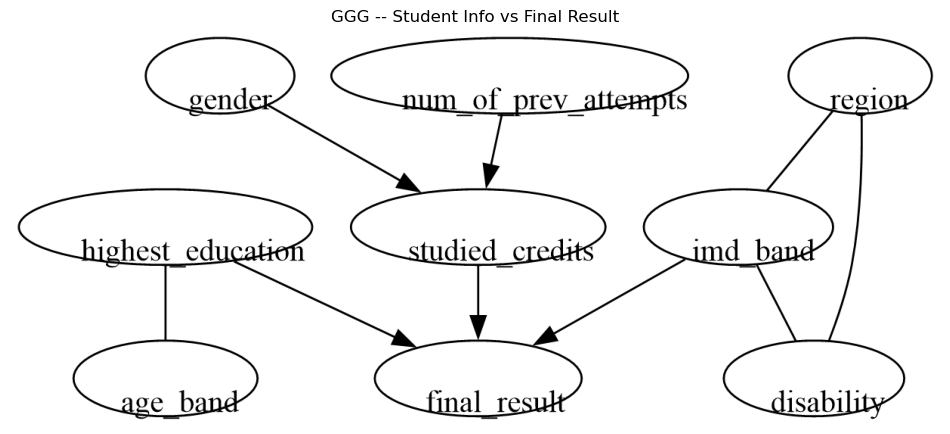

In [58]:
pyd1_ggg = GraphUtils.to_pydot(cg1_ggg.G, labels=node_names_dag1_ggg)

for node in pyd1_ggg.get_nodes():
    node.set_fontsize('11')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.08')

png_bytes1_ggg = pyd1_ggg.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\GGG_DAG1_studentinfo_vs_finalresult.png", "wb") as f:
    f.write(png_bytes1_ggg)

img1_ggg = mpimg.imread(io.BytesIO(png_bytes1_ggg), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img1_ggg)
plt.axis('off')
plt.title("GGG -- Student Info vs Final Result")
plt.show()

### rechecking as no node directing to final result 

In [48]:
from scipy.stats import chi2_contingency

for col in demo_cols_ggg:
    contingency = pd.crosstab(dag1_data_ggg[col], dag1_data_ggg['final_result'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col} vs final_result: p = {p:.6f}")

gender vs final_result: p = 0.322102
region vs final_result: p = 0.000236
highest_education vs final_result: p = 0.000000
imd_band vs final_result: p = 0.000061
age_band vs final_result: p = 0.024394
num_of_prev_attempts vs final_result: p = 0.315389
studied_credits vs final_result: p = 0.001516
disability vs final_result: p = 0.309056


In [50]:
from itertools import combinations

for col1, col2 in combinations(demo_cols_ggg, 2):
    contingency = pd.crosstab(dag1_data_ggg[col1], dag1_data_ggg[col2])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col1} vs {col2}: p = {p:.6f}")

gender vs region: p = 0.143672
gender vs highest_education: p = 0.564288
gender vs imd_band: p = 0.722128
gender vs age_band: p = 0.070091
gender vs num_of_prev_attempts: p = 0.550003
gender vs studied_credits: p = 0.002211
gender vs disability: p = 0.610692
region vs highest_education: p = 0.000002
region vs imd_band: p = 0.000000
region vs age_band: p = 0.430105
region vs num_of_prev_attempts: p = 0.520521
region vs studied_credits: p = 0.874570
region vs disability: p = 0.000042
highest_education vs imd_band: p = 0.000422
highest_education vs age_band: p = 0.000001
highest_education vs num_of_prev_attempts: p = 0.160994
highest_education vs studied_credits: p = 0.996087
highest_education vs disability: p = 0.001818
imd_band vs age_band: p = 0.004833
imd_band vs num_of_prev_attempts: p = 0.759588
imd_band vs studied_credits: p = 0.022344
imd_band vs disability: p = 0.004387
age_band vs num_of_prev_attempts: p = 0.823886
age_band vs studied_credits: p = 0.891728
age_band vs disability

In [52]:
for col in demo_cols_ggg:
    print(col, dag1_data_ggg[col].nunique())

gender 2
region 13
highest_education 5
imd_band 10
age_band 3
num_of_prev_attempts 3
studied_credits 10
disability 2


solution: Rerun with a higher alpha (e.g., 0.10 instead of 0.05), which makes PC more willing to keep edges 

## Assessments vs Final Result

In [63]:
ass_cols_ggg = [f'ass_{i}_score' for i in range(1, 10)]

df[ass_cols_ggg] = df[ass_cols_ggg].fillna(-1)

dag2_data_ggg = df[ass_cols_ggg + ['final_result']].copy()

for col in ass_cols_ggg:
    dag2_data_ggg[col] = pd.qcut(dag2_data_ggg[col], q=4, labels=False, duplicates='drop')

print(dag2_data_ggg.shape)
print(dag2_data_ggg.nunique())

(2534, 10)
ass_1_score     4
ass_2_score     3
ass_3_score     3
ass_4_score     2
ass_5_score     2
ass_6_score     2
ass_7_score     2
ass_8_score     3
ass_9_score     1
final_result    4
dtype: int64


In [66]:
node_names_dag2_ggg = list(dag2_data_ggg.columns)
nodes_dag2_ggg = [GraphNode(name) for name in node_names_dag2_ggg]

bk2_ggg = BackgroundKnowledge()

final_result_node2_ggg = nodes_dag2_ggg[node_names_dag2_ggg.index('final_result')]

# Rule 5: final_result cannot cause any assessment
for n in nodes_dag2_ggg:
    if n != final_result_node2_ggg:
        bk2_ggg.add_forbidden_by_node(final_result_node2_ggg, n)

# Rule 3: sequential order -- ass_j cannot cause ass_i if j > i
for j in range(1, 10):
    for i in range(1, j):
        node_j = nodes_dag2_ggg[node_names_dag2_ggg.index(f'ass_{j}_score')]
        node_i = nodes_dag2_ggg[node_names_dag2_ggg.index(f'ass_{i}_score')]
        bk2_ggg.add_forbidden_by_node(node_j, node_i)

# Sanity check
ass1_node_ggg = nodes_dag2_ggg[node_names_dag2_ggg.index('ass_1_score')]
ass8_node_ggg = nodes_dag2_ggg[node_names_dag2_ggg.index('ass_8_score')]
print("ass_8 -> ass_1 forbidden:", bk2_ggg.is_forbidden(ass8_node_ggg, ass1_node_ggg))
print("final_result -> ass_1 forbidden:", bk2_ggg.is_forbidden(final_result_node2_ggg, ass1_node_ggg))

ass_8 -> ass_1 forbidden: True
final_result -> ass_1 forbidden: True


In [68]:
data2_ggg = dag2_data_ggg.to_numpy()

cg2_ggg = pc(data2_ggg, alpha=0.05, indep_test='gsq', background_knowledge=bk2_ggg, node_names=node_names_dag2_ggg)

print("Number of edges:", cg2_ggg.G.get_num_edges())

  0%|          | 0/10 [00:00<?, ?it/s]

Number of edges: 22


In [70]:
for edge in cg2_ggg.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

ass_1_score [TAIL] -- [ARROW] ass_2_score
ass_1_score [TAIL] -- [ARROW] ass_3_score
ass_1_score [TAIL] -- [ARROW] ass_4_score
ass_1_score [TAIL] -- [ARROW] final_result
ass_2_score [TAIL] -- [ARROW] ass_3_score
ass_2_score [TAIL] -- [ARROW] ass_4_score
ass_2_score [TAIL] -- [ARROW] ass_6_score
ass_3_score [TAIL] -- [ARROW] ass_5_score
ass_3_score [TAIL] -- [ARROW] ass_8_score
ass_3_score [TAIL] -- [ARROW] final_result
ass_4_score [TAIL] -- [ARROW] ass_5_score
ass_4_score [TAIL] -- [ARROW] ass_6_score
ass_4_score [TAIL] -- [ARROW] ass_7_score
ass_4_score [TAIL] -- [ARROW] final_result
ass_5_score [TAIL] -- [ARROW] ass_6_score
ass_5_score [TAIL] -- [ARROW] ass_7_score
ass_5_score [TAIL] -- [ARROW] final_result
ass_6_score [TAIL] -- [ARROW] ass_8_score
ass_6_score [TAIL] -- [ARROW] final_result
ass_7_score [TAIL] -- [ARROW] ass_8_score
ass_7_score [TAIL] -- [ARROW] final_result
ass_8_score [TAIL] -- [ARROW] final_result


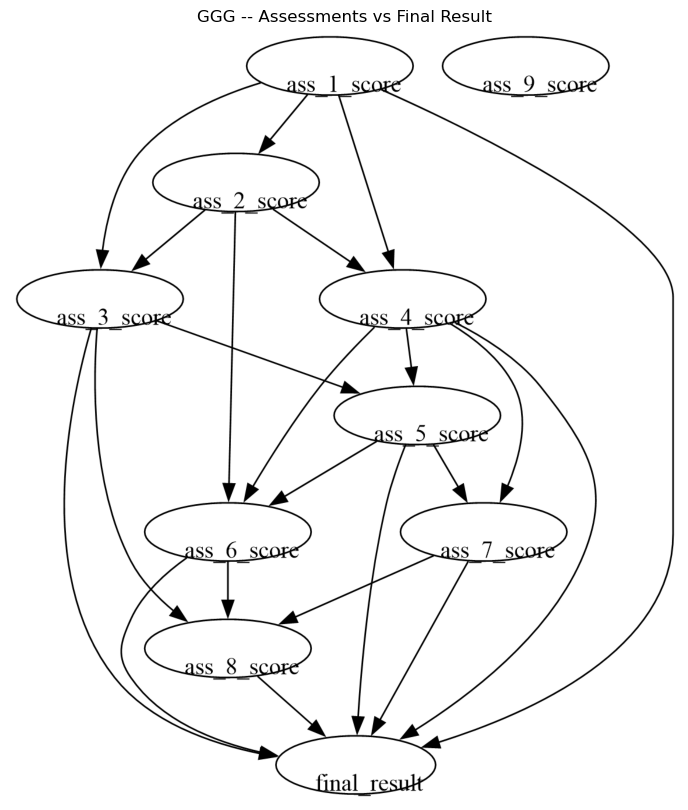

In [72]:
pyd2_ggg = GraphUtils.to_pydot(cg2_ggg.G, labels=node_names_dag2_ggg)

for node in pyd2_ggg.get_nodes():
    node.set_fontsize('11')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.08')

png_bytes2_ggg = pyd2_ggg.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\GGG_DAG2_assessments_vs_finalresult.png", "wb") as f:
    f.write(png_bytes2_ggg)

img2_ggg = mpimg.imread(io.BytesIO(png_bytes2_ggg), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img2_ggg)
plt.axis('off')
plt.title("GGG -- Assessments vs Final Result")
plt.show()

## Individual Clicks vs Final Result 

In [75]:
raw_click_cols_ggg = ['clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_oucontent',
                       'clicks_quiz', 'clicks_resource', 'clicks_subpage']

clicks_raw_ggg = df[raw_click_cols_ggg].fillna(0)

for col in raw_click_cols_ggg:
    print(col, "nonzero:", (clicks_raw_ggg[col] > 0).sum(), "unique:", clicks_raw_ggg[col].nunique())

clicks_forumng nonzero: 1892 unique: 411
clicks_glossary nonzero: 1131 unique: 67
clicks_homepage nonzero: 2364 unique: 404
clicks_oucontent nonzero: 2277 unique: 598
clicks_quiz nonzero: 1989 unique: 248
clicks_resource nonzero: 2322 unique: 166
clicks_subpage nonzero: 2280 unique: 118


In [77]:
dag3_data_ggg = clicks_raw_ggg.copy()

for col in raw_click_cols_ggg:
    dag3_data_ggg[col] = pd.qcut(dag3_data_ggg[col], q=4, labels=False, duplicates='drop')

dag3_data_ggg['final_result'] = df['final_result'].values

print(dag3_data_ggg.shape)
for col in dag3_data_ggg.columns:
    print(col, dag3_data_ggg[col].nunique())

(2534, 8)
clicks_forumng 3
clicks_glossary 2
clicks_homepage 4
clicks_oucontent 4
clicks_quiz 4
clicks_resource 4
clicks_subpage 4
final_result 4


In [79]:
node_names_dag3_ggg = list(dag3_data_ggg.columns)
nodes_dag3_ggg = [GraphNode(name) for name in node_names_dag3_ggg]

bk3_ggg = BackgroundKnowledge()

final_result_node3_ggg = nodes_dag3_ggg[node_names_dag3_ggg.index('final_result')]

# Rule 6 (per-column): final_result cannot cause any individual click variable
for n in nodes_dag3_ggg:
    if n != final_result_node3_ggg:
        bk3_ggg.add_forbidden_by_node(final_result_node3_ggg, n)

# Sanity check
clicks_resource_node_ggg = nodes_dag3_ggg[node_names_dag3_ggg.index('clicks_resource')]
print("final_result -> clicks_resource forbidden:", bk3_ggg.is_forbidden(final_result_node3_ggg, clicks_resource_node_ggg))

final_result -> clicks_resource forbidden: True


In [81]:
data3_ggg = dag3_data_ggg.to_numpy()

cg3_ggg = pc(data3_ggg, alpha=0.05, indep_test='gsq', background_knowledge=bk3_ggg, node_names=node_names_dag3_ggg)

print("Number of edges:", cg3_ggg.G.get_num_edges())

  0%|          | 0/8 [00:00<?, ?it/s]

Number of edges: 19


In [83]:
for edge in cg3_ggg.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

clicks_glossary [TAIL] -- [ARROW] clicks_forumng
clicks_homepage [TAIL] -- [ARROW] clicks_forumng
clicks_resource [TAIL] -- [ARROW] clicks_forumng
clicks_forumng [TAIL] -- [ARROW] final_result
clicks_glossary [TAIL] -- [TAIL] clicks_homepage
clicks_glossary [TAIL] -- [ARROW] clicks_oucontent
clicks_glossary [TAIL] -- [TAIL] clicks_quiz
clicks_glossary [TAIL] -- [ARROW] clicks_subpage
clicks_homepage [TAIL] -- [ARROW] clicks_oucontent
clicks_homepage [TAIL] -- [TAIL] clicks_quiz
clicks_homepage [TAIL] -- [TAIL] clicks_resource
clicks_homepage [TAIL] -- [ARROW] clicks_subpage
clicks_quiz [TAIL] -- [ARROW] clicks_oucontent
clicks_subpage [TAIL] -- [ARROW] clicks_oucontent
clicks_oucontent [TAIL] -- [ARROW] final_result
clicks_quiz [TAIL] -- [ARROW] clicks_subpage
clicks_quiz [TAIL] -- [ARROW] final_result
clicks_resource [TAIL] -- [ARROW] clicks_subpage
clicks_subpage [TAIL] -- [ARROW] final_result


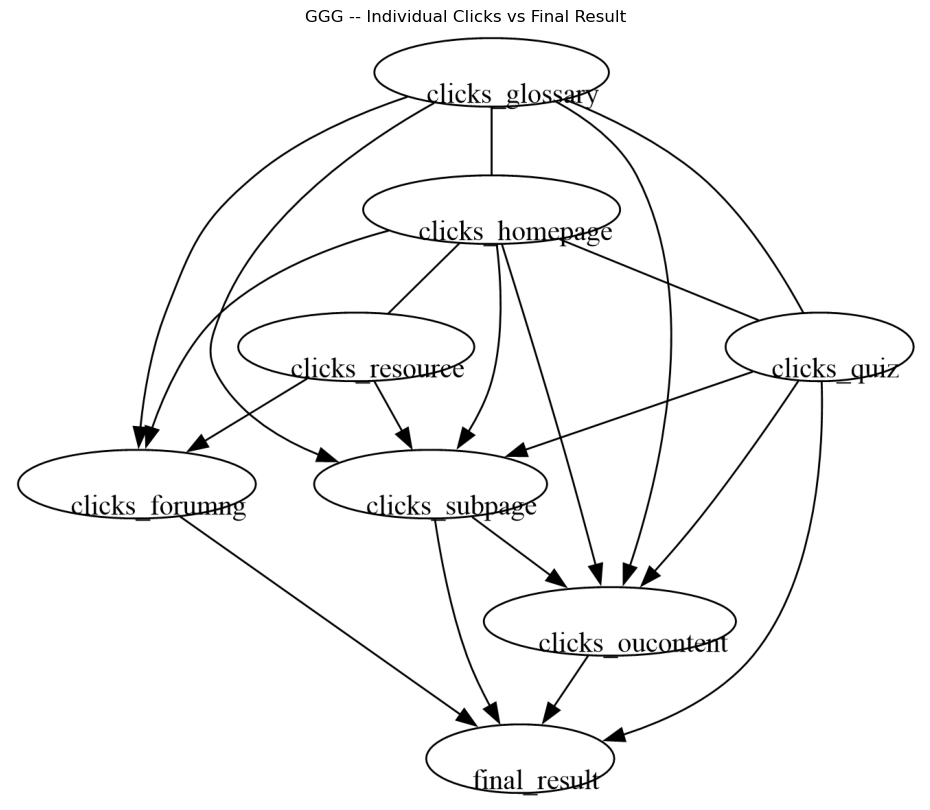

In [85]:
pyd3_ggg = GraphUtils.to_pydot(cg3_ggg.G, labels=node_names_dag3_ggg)

for node in pyd3_ggg.get_nodes():
    node.set_fontsize('11')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.08')

png_bytes3_ggg = pyd3_ggg.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\GGG_DAG3_clicks_vs_finalresult.png", "wb") as f:
    f.write(png_bytes3_ggg)

img3_ggg = mpimg.imread(io.BytesIO(png_bytes3_ggg), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img3_ggg)
plt.axis('off')
plt.title("GGG -- Individual Clicks vs Final Result")
plt.show()

## assessment vs VLE clicks

In [1]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.stats import chi2_contingency
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledgeOrientUtils import *
from causallearn.graph.GraphNode import GraphNode
from causallearn.utils.cit import CIT
from causallearn.utils.GraphUtils import GraphUtils

dot_path = r"C:\Users\Disha Sharma\.conda\envs\analytics\Library\bin\dot.exe"

In [3]:
df_ggg_raw = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\GGG.csv")

print(df_ggg_raw.shape)
df_ggg_raw.head()

(2534, 38)


,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,ass_8_score,ass_9_date,ass_9_score,clicks_forumng,clicks_glossary,clicks_homepage,clicks_oucontent,clicks_quiz,clicks_resource,clicks_subpage
0,2013J,24391,M,East Midlands Region,A Level or Equivalent,80-90%,0-35,0,30,N,...,80.0,220.0,100.0,62.0,2.0,130.0,357.0,120.0,18.0,23.0
1,2013J,26023,M,North Western Region,Lower Than A Level,10-20,35-55,0,30,N,...,100.0,220.0,100.0,118.0,1.0,315.0,151.0,105.0,83.0,13.0
2,2013J,32239,F,London Region,A Level or Equivalent,30-40%,0-35,0,30,N,...,80.0,NaN,NaN,140.0,0.0,181.0,178.0,88.0,18.0,15.0
3,2013J,35001,F,East Midlands Region,Lower Than A Level,70-80%,35-55,0,30,N,...,NaN,NaN,NaN,3.0,0.0,24.0,36.0,1.0,3.0,10.0
4,2013J,60405,F,Yorkshire Region,A Level or Equivalent,10-20,35-55,0,30,N,...,60.0,231.0,100.0,127.0,4.0,176.0,360.0,143.0,27.0,15.0


In [5]:
ass_cols_ggg = [f"ass_{i}_score" for i in range(1, 10)]
click_cols_ggg = [col for col in df_ggg_raw.columns if col.startswith('clicks_')]

df_ggg_sel = df_ggg_raw[ass_cols_ggg + click_cols_ggg].copy()

# scores NaN -> -1, clicks NaN -> 0
df_ggg_sel[ass_cols_ggg] = df_ggg_sel[ass_cols_ggg].fillna(-1)
df_ggg_sel[click_cols_ggg] = df_ggg_sel[click_cols_ggg].fillna(0)

# quartile binning
for col in ass_cols_ggg + click_cols_ggg:
    df_ggg_sel[col] = pd.qcut(df_ggg_sel[col], q=4, labels=False, duplicates='drop')

print(df_ggg_sel.shape)
df_ggg_sel.nunique()

(2534, 16)


ass_1_score         4
ass_2_score         3
ass_3_score         3
ass_4_score         2
ass_5_score         2
ass_6_score         2
ass_7_score         2
ass_8_score         3
ass_9_score         1
clicks_forumng      3
clicks_glossary     2
clicks_homepage     4
clicks_oucontent    4
clicks_quiz         4
clicks_resource     4
clicks_subpage      4
dtype: int64

In [7]:
df_ggg_sel = df_ggg_sel.drop(columns=['ass_9_score'])
ass_cols_ggg = [col for col in ass_cols_ggg if col != 'ass_9_score']

print(df_ggg_sel.shape)
print(ass_cols_ggg)

(2534, 15)
['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score']


In [9]:
node_names_ggg = list(df_ggg_sel.columns)
data_ggg = df_ggg_sel.values

bk_ggg = BackgroundKnowledge()

# Rule 3: sequential assessment order
for i in range(1, 9):
    for j in range(1, 9):
        if j > i:
            bk_ggg.add_forbidden_by_node(
                GraphNode(f"ass_{j}_score"), GraphNode(f"ass_{i}_score")
            )

# Rule 6 variant: assessment scores cannot cause clicks
for ass in ass_cols_ggg:
    for click in click_cols_ggg:
        bk_ggg.add_forbidden_by_node(GraphNode(ass), GraphNode(click))

cg_ggg = pc(data_ggg, 0.05, 'gsq', node_names=node_names_ggg, background_knowledge=bk_ggg, depth=3, show_progress=True)
print(cg_ggg.G.get_num_edges())

  0%|          | 0/15 [00:00<?, ?it/s]

38


In [11]:
for edge in cg_ggg.G.get_graph_edges():
    print(edge)

ass_1_score --> ass_2_score
ass_1_score --> ass_3_score
ass_1_score --> ass_4_score
clicks_forumng --> ass_1_score
clicks_oucontent --> ass_1_score
clicks_quiz --> ass_1_score
ass_2_score --> ass_3_score
ass_2_score --> ass_6_score
clicks_quiz --> ass_2_score
ass_3_score --> ass_6_score
ass_3_score --> ass_7_score
ass_3_score --> ass_8_score
clicks_oucontent --> ass_3_score
clicks_quiz --> ass_3_score
ass_4_score --> ass_5_score
clicks_quiz --> ass_4_score
ass_5_score --> ass_6_score
ass_5_score --> ass_7_score
clicks_oucontent --> ass_5_score
clicks_quiz --> ass_5_score
clicks_quiz --> ass_6_score
ass_7_score --> ass_8_score
clicks_oucontent --> ass_7_score
clicks_quiz --> ass_7_score
clicks_oucontent --> ass_8_score
clicks_quiz --> ass_8_score
clicks_forumng --> clicks_glossary
clicks_forumng --- clicks_homepage
clicks_homepage --> clicks_glossary
clicks_oucontent --> clicks_glossary
clicks_subpage --> clicks_glossary
clicks_homepage --> clicks_oucontent
clicks_homepage --- clicks_qu

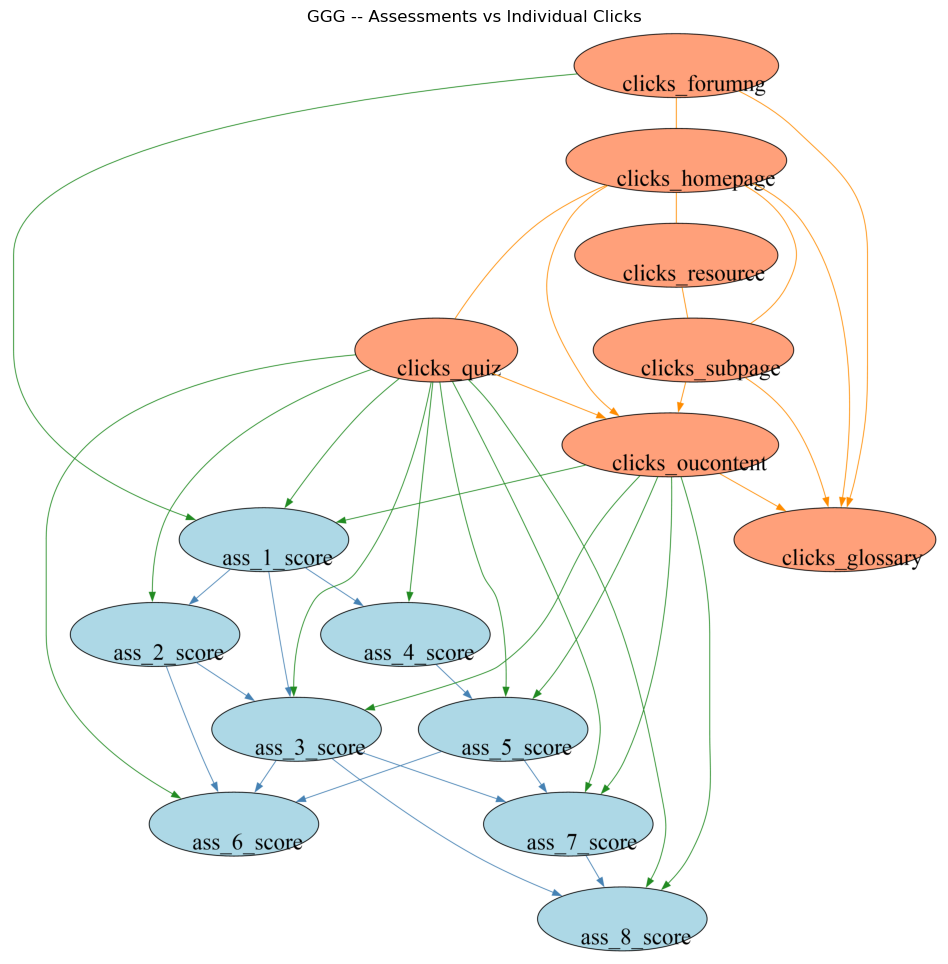

In [13]:
pyd_ggg_assclicks = GraphUtils.to_pydot(cg_ggg.G, labels=node_names_ggg)

for node in pyd_ggg_assclicks.get_nodes():
    name = node.get_name().strip('"')
    if name.isdigit():
        actual_name = node_names_ggg[int(name)]
    else:
        continue
    if actual_name.startswith('ass_'):
        node.set_style('filled')
        node.set_fillcolor('lightblue')
    elif actual_name.startswith('clicks_'):
        node.set_style('filled')
        node.set_fillcolor('lightsalmon')
    node.set_fontsize('20')
    node.set_fixedsize('false')
    node.set_margin('0.3,0.20')

for edge in pyd_ggg_assclicks.get_edges():
    src_idx = int(edge.get_source())
    dst_idx = int(edge.get_destination())
    src = node_names_ggg[src_idx]
    dst = node_names_ggg[dst_idx]
    if src.startswith('ass_') and dst.startswith('ass_'):
        edge.set_color('steelblue')
    elif src.startswith('clicks_') and dst.startswith('clicks_'):
        edge.set_color('darkorange')
    else:
        edge.set_color('forestgreen')

png_bytes_ggg_assclicks = pyd_ggg_assclicks.create_png(prog=dot_path)
with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\GGG_DAG4_assessments_vs_clicks.png", "wb") as f:
    f.write(png_bytes_ggg_assclicks)
img_ggg_assclicks = mpimg.imread(io.BytesIO(png_bytes_ggg_assclicks), format='png')
plt.figure(figsize=(14, 12))
plt.imshow(img_ggg_assclicks)
plt.axis('off')
plt.title("GGG -- Assessments vs Individual Clicks")
plt.show()